# Задание 1. Симуляция АА теста


In [1]:
import uuid
import pandas as pd
import numpy as np
from scipy import stats
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)


In [2]:
# Генерация 10000 пользователей с помощью UUID4, с вероятностью 10% action = 1

df = pd.DataFrame({
    'user_id': [str(uuid.uuid4()) for _ in range(10000)],
    'action' : np.random.binomial(1, 0.1, size=10000)
})

print(df.head())
print(df['action'].mean())


                                user_id  action
0  a66f2785-90b0-4048-a4cd-6f123ef91961       0
1  17bd3f94-d6d3-41e0-ae69-7cdfd4c31a84       1
2  e438c5f9-2c83-4075-9418-9f0fa758d8ba       0
3  f3d8ceaf-d4b6-461a-a1d7-98e274bdf2bf       0
4  a24c6394-67a7-4612-92a6-7d7b7f4fb8db       0
0.0961


In [3]:
# Оценка отличия конверсии в двух подвыборках (chi-test, t-test, u-test, bootstrap)
def estimation(sample1, sample2, n_bootstrap=1000):

  control = sample1['action'].values
  variant = sample2['action'].values

  # chi-test
  contingency = np.array([
        [control.sum(), len(control) - control.sum()],
        [variant.sum(), len(variant) - variant.sum()]])
  _, chi_p, _, _ = stats.chi2_contingency(contingency, correction=False)

  # t-test
  _, t_p = stats.ttest_ind(control, variant, equal_var=False)

  # u-test
  _, u_p = stats.mannwhitneyu(control, variant, alternative="two-sided")

  # bootstrap
  boot_diffs = []
  for _ in range(n_bootstrap):
      c_sample = np.random.choice(control, size=len(control), replace=True)
      v_sample = np.random.choice(variant, size=len(variant), replace=True)
      boot_diffs.append(v_sample.mean() - c_sample.mean())

  boot_diffs = np.array(boot_diffs)

  boot_p = 2 * min((boot_diffs >= 0).mean(),(boot_diffs <= 0).mean())

  # итоговая строка
  return {
    'chi2_p': chi_p,
    'ttest_p': t_p,
    'utest_p': u_p,
    'bootstrap_p': boot_p
}


In [4]:
# Сплитование одного пользователя (назначение группы, подразумевается сплит 50/50)
def split(userid, salt):
  str2hash = str(userid) + str(salt)
  result = int((hashlib.md5(str2hash.encode())).hexdigest(),16) % 100
  if result < 50:
    return 'control'
  else:
    return 'test'



In [5]:
# 1000 итераций: сплитование пользователей (соль - номер итерации), проверка различия конверсий

pval = {}
for i in range(1000):

  df_new = df.copy()
  df_new['group'] = [split(uid, i) for uid in df_new['user_id']]

  sample1 = df_new[df_new['group'] == 'control'].copy()
  sample2 = df_new[df_new['group'] == 'test'].copy()
  pval[i] = estimation(sample1, sample2)



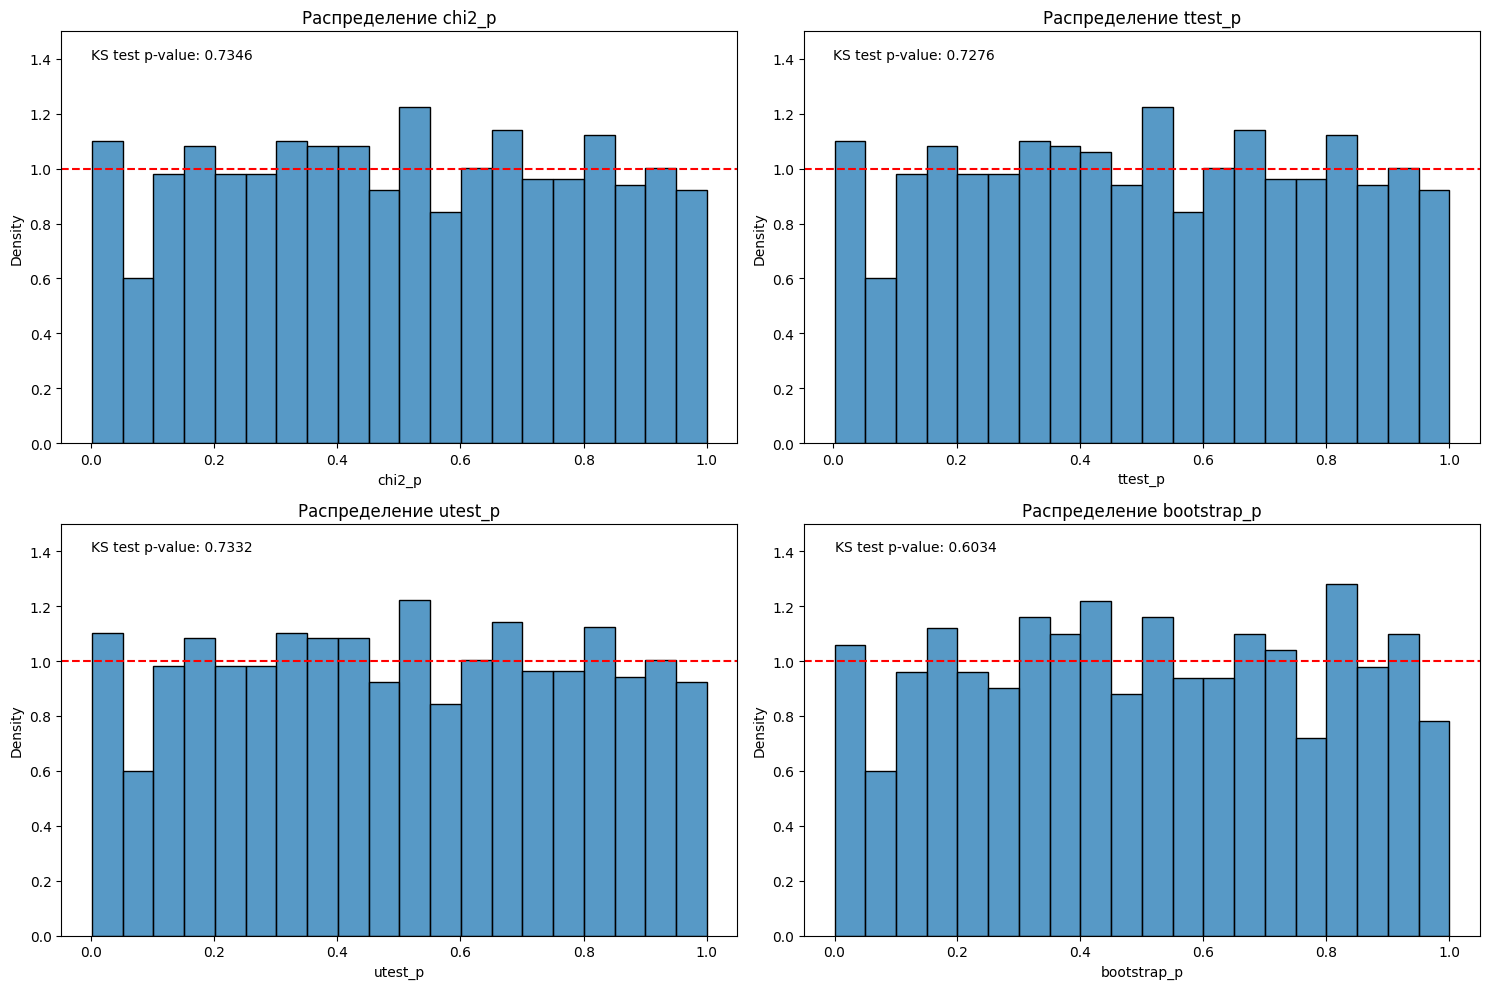

chi2_p      : KS p-value = 0.7346 - Не отвергаем Н0 о равномерном распределении
ttest_p     : KS p-value = 0.7276 - Не отвергаем Н0 о равномерном распределении
utest_p     : KS p-value = 0.7332 - Не отвергаем Н0 о равномерном распределении
bootstrap_p : KS p-value = 0.6034 - Не отвергаем Н0 о равномерном распределении


In [6]:
# Распределение p-value для использованных критериев, теcт Колмогорова-Смирнова на соответствие равномерному распределению

df_pvalues = pd.DataFrame.from_dict(pval, orient='index')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
columns = df_pvalues.columns

for i, col in enumerate(columns):
    # гистограмма p-values
    sns.histplot(df_pvalues[col], bins=20, kde=False, ax=axes[i], stat="density")
    axes[i].axhline(1, color='red', linestyle='--')
    axes[i].set_title(f'Распределение {col}')
    axes[i].set_ylim(0, 1.5)

    # тест Колмогорова-Смирнова
    ks_stat, ks_p = stats.kstest(df_pvalues[col], 'uniform')
    axes[i].annotate(f'KS test p-value: {ks_p:.4f}', xy=(0, 1.4))

plt.tight_layout()
plt.show()

# итоги
for col in columns:
    _, ks_p = stats.kstest(df_pvalues[col], 'uniform')
    res = 'Не отвергаем Н0 о равномерном распределении' if ks_p > 0.05 else 'Отвергаем Н0 о равномерном распределении'
    print(f'{col:12}: KS p-value = {ks_p:.4f} - {res}')

Полученное распределение p-value для всех стат критериев можно считать равномерным. Соответственно, сплитование корректно.

# Задание 2. Симуляция АБ теста




In [7]:
import uuid
import pandas as pd
import numpy as np
from scipy import stats
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)


In [8]:
# Оценка конверсии - из предыдущего задания
def estimation(sample1, sample2, n_bootstrap=1000):

  control = sample1['action'].values
  variant = sample2['action'].values

  # chi-test
  contingency = np.array([
        [control.sum(), len(control) - control.sum()],
        [variant.sum(), len(variant) - variant.sum()]])
  _, chi_p, _, _ = stats.chi2_contingency(contingency, correction=False)

  # t-test
  _, t_p = stats.ttest_ind(control, variant, equal_var=False)

  # u-test
  _, u_p = stats.mannwhitneyu(control, variant, alternative="two-sided")

  # bootstrap
  boot_diffs = []
  for _ in range(n_bootstrap):
      c_sample = np.random.choice(control, size=len(control), replace=True)
      v_sample = np.random.choice(variant, size=len(variant), replace=True)
      boot_diffs.append(v_sample.mean() - c_sample.mean())

  boot_diffs = np.array(boot_diffs)

  boot_p = 2 * min((boot_diffs >= 0).mean(),(boot_diffs <= 0).mean())

  # итоговая строка
  return {
    'chi2_p': chi_p,
    'ttest_p': t_p,
    'utest_p': u_p,
    'bootstrap_p': boot_p
}

# Сплитование одного пользователя - из предыдущего задания
def split(userid, salt):
  str2hash = str(userid) + str(salt)
  result = int((hashlib.md5(str2hash.encode())).hexdigest(),16) % 100
  if result < 50:
    return 'control'
  else:
    return 'test'


In [9]:
# Процедура (генерация, сплитование, добавление эффекта, оценка конверсии, вычисление мощности) для n_users пользователей
def proc(n_users, n_iterations=1000, true_effect=0.01):

  # Создаем n_users пользователей, с вероятностью 10% action=1
  df = pd.DataFrame({
      'user_id': [str(uuid.uuid4()) for _ in range(n_users)],
      'action' : np.random.binomial(1, 0.1, size=n_users)
  })

  pvals = {
        'chi2': [],
        'ttest': [],
        'utest': [],
        'bootstrap': []
    }
  # Сплитование n_iterations раз:
  for i in range(n_iterations):

    df_new = df.copy()
    # Соль - номер итерации при сплитовании + количество пользователей, для которых проводится итерация
    df_new['group'] = [split(uid, i+n_users) for uid in df_new['user_id']]
    control_gr = df_new[df_new['group'] == 'control'].copy()
    test_gr = df_new[df_new['group'] == 'test'].copy()

    # На каждой итерации генерируем новые ответы в обеих группах
    control_gr['action'] = np.random.binomial(1, 0.1, size=len(control_gr))
    test_gr['action'] = np.random.binomial(1, 0.1 + true_effect, size=len(test_gr))

    # Оценка значимости различия конверсий
    res = estimation(control_gr, test_gr)

    pvals['chi2'].append(res['chi2_p'])
    pvals['ttest'].append(res['ttest_p'])
    pvals['utest'].append(res['utest_p'])
    pvals['bootstrap'].append(res['bootstrap_p'])

  # считаем мощность по каждому тесту
  power = {
        k: (np.array(v) < 0.05).mean()
        for k, v in pvals.items()}

  return power


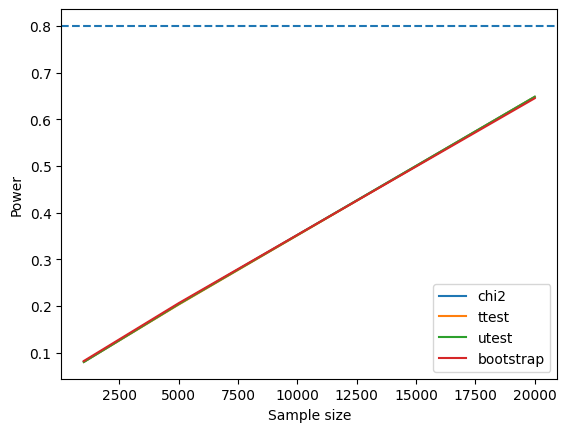

In [10]:
# Процедура для 1000/5000/20000 пользователей, построение графика мощности
users_n = [1000, 5000, 20000]

results = {
    'chi2': [],
    'ttest': [],
    'utest': [],
    'bootstrap': []
}

for n in users_n:
    power = proc(n)
    for k in results:
        results[k].append(power[k])

# график
for k, v in results.items():
    plt.plot(users_n, v, label=k)

plt.axhline(0.8, linestyle='--')  # линия 80% мощности
plt.xlabel('Sample size')
plt.ylabel('Power')
plt.legend()
plt.show()


Графики показывают, что добиться мощности в 80% при 1% истинного эффекта и 1000/5000/20000 пользователей невозможно (наблюдаемая мощность для 20000 пользователей даже не достигает 70%, в других попытках она не достигала и 50%).
Действительно, по (приблизительной) формуле размера выборки:
n_per_group = (1.96 + 0.84)^2 * (0.1 * 0.9 + 0.11 * 0.89) / 0.01^2 = 14732 - на одну группу
Поэтому для повышения мощности нужно провести эксперимент на большем количестве пользователей

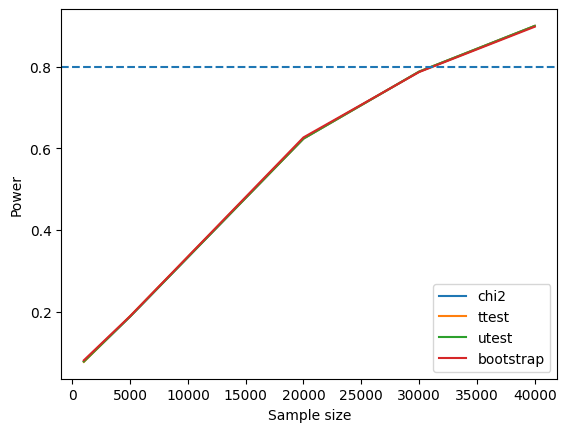

In [11]:
# Процедура для 1000/5000/20000/30000/40000 пользователей, построение графика мощности
users_n = [1000, 5000, 20000, 30000, 40000]

results = {
    'chi2': [],
    'ttest': [],
    'utest': [],
    'bootstrap': []
}

for n in users_n:
    power = proc(n)
    for k in results:
        results[k].append(power[k])

# график
for k, v in results.items():
    plt.plot(users_n, v, label=k)

plt.axhline(0.8, linestyle='--')  # линия 80% мощности
plt.xlabel('Sample size')
plt.ylabel('Power')
plt.legend()
plt.show()


Использованные критерии показывают практически одинаковую статистическую мощность, их линии на графике сливаются.

В данной попытке для 20000 пользователей наблюдается примерно 65% мощность, 80% достигается при уровне количества пользователей примерно в 30000 пользователей, что согласуется с оценкой размера групп по формуле